## Infos Iniciais

### Objetivo
A operadora de comunicações Interconnect gostaria de ser capaz de predizer a rotatividade de seus clientes. Se for descoberto que um usuário está planejando trocar de operadora, a empresa oferecerá-lhe códigos promocionais e opções de plano especiais. A equipe de marketing da Interconnect coletou alguns dados pessoais da sua clientela, incluindo a informação sobre seus planos e contratos.

### Serviços Oferecidos pela empresa
A Interconnect fornece principalmente dois tipos de serviços:

1. Telefonia fixa. O telefone pode ser conectado a várias linhas ao mesmo tempo.
2. Internet. A rede pode ser estabelecida através de uma linha telefônica (DSL, *digital subscriber line - linha digital de assinante*) ou através de um cabo de fibra óptica.

Alguns outros serviços fornecidos pela empresa incluem:

- Segurança na Internet: software de antivírus (*DeviceProtection* - proteção de dispositivos) e um bloqueador de sites maliciosos (*OnlineSecurity* - segurança online).
- Uma linha dedicada de suporte técnico (*TechSupport*).
- Armazenamento de arquivos na nuvem e backup de dados (*OnlineBackup*).
- Streaming de TV (*StreamingTV*) e um diretório de filmes (*StreamingMovies*).

Os clientes podem escolher entre fazer um pagamento mensal e assinar um contrato de 1 ou 2 anos. Eles podem usar vários métodos de pagamento e receber uma fatura eletrônica após a transação.

### Descrição dos Dados

Os dados consistem de arquivos obtidos de fontes diferentes:

- `contract.csv` — informação contratual;
- `personal.csv` — dados pessoais do cliente;
- `internet.csv` — informação sobre serviços de Internet;
- `phone.csv` — informação sobre serviços de telefonia.

Em cada arquivo, a coluna `customerID` contém um código unívoco atribuído a cada cliente. A informação contratual é válida a partir de 1 de fevereiro de 2020.

## Análise Exploratória de Dados

In [ ]:
#Importação de bibliotecas

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


In [ ]:
#carregamento e unificação dos dados

path = '/datasets/final_provider/'

contract = pd.read_csv(path + 'contract.csv')
personal = pd.read_csv(path + 'personal.csv')
internet = pd.read_csv(path + 'internet.csv')
phone = pd.read_csv(path + 'phone.csv')

data = contract.merge(personal, on='customerID', how='left') \
               .merge(internet, on='customerID', how='left') \
               .merge(phone, on='customerID', how='left')


In [ ]:
data.info()
data.head()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


In [4]:
# Converter a coluna TotalCharges para formato numérico.
data['TotalCharges'] = data['TotalCharges'].fillna(0)


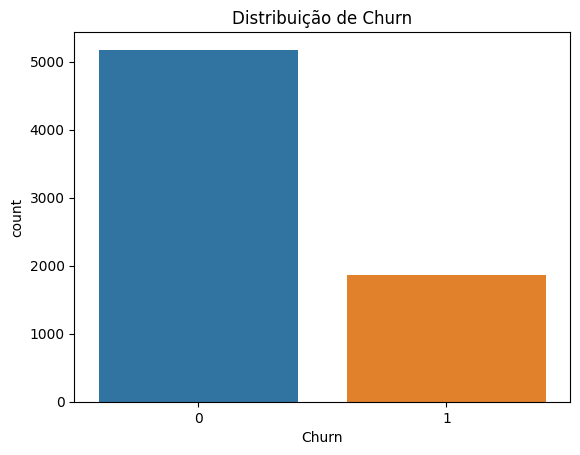

In [ ]:
#Análise de variável alvo
# 1 = clinete cancelou // 0 = cliente permaneceu

data['Churn'] = (data['EndDate'] != 'No').astype(int)
data['Churn'].value_counts(normalize=True)

sns.countplot(data=data, x='Churn')
plt.title('Distribuição de Churn')
plt.show()


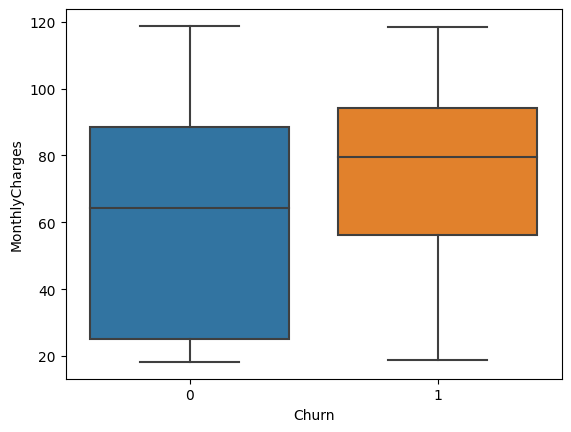

In [ ]:
sns.boxplot(data=data, x='Churn', y='MonthlyCharges')
plt.show()


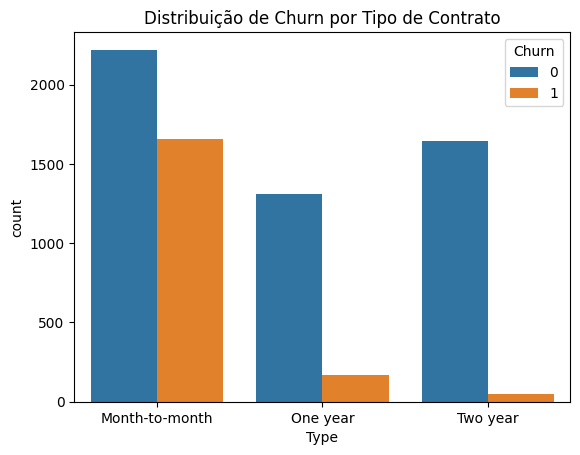

In [ ]:
sns.countplot(data=data, x='Type', hue='Churn')
plt.title('Distribuição de Churn por Tipo de Contrato')
plt.show()


#### Análise

Clientes com contratos mensais e mensalidades mais altas apresentam maior taxa de churn. Serviços adicionais como suporte técnico e segurança online parecem estar associados a maior retenção.


## Desenvolvimento do Modelo

In [8]:
#Preparação dos dados
colunas_para_remover = ['customerID', 'Churn', 'EndDate', 'BeginDate']

X = data.drop(colunas_para_remover, axis=1)
y = data['Churn']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [ ]:
# Regressão Logística

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight={0: 1, 1: 2}
    ))
])


In [ ]:
#Random Forest

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    ))
])


In [ ]:
# Instalar e importar XGBoost e LightGBM
!pip install xgboost lightgbm

import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import recall_score, precision_score


In [ ]:
# XGBoost
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=2,
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False
    ))
])


In [ ]:
# LightGBM
lgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        class_weight='balanced',
        random_state=42,
        verbose=-1 
    ))
])


In [ ]:
#Treinamento e Avaliação

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

for name, model in {'LogReg': log_reg, 'RF': rf, 'XGBoost': xgb_model, 'Light GBM': lgb_model}.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    print(f'{name} AUC-ROC: {auc:.3f}')


LogReg AUC-ROC: 0.825
RF AUC-ROC: 0.806
XGBoost AUC-ROC: 0.801
Light GBM AUC-ROC: 0.797


In [ ]:
# Comparar todos os modelos com threshold 0.2
modelos = {
    'LogReg': log_reg,
    'Random Forest': rf, 
    'XGBoost': xgb_model,
    'LightGBM': lgb_model
}

resultados_comparacao = {}

for nome, modelo in modelos.items():
    y_proba_modelo = modelo.predict_proba(X_test)[:, 1]
    
    # Testar threshold 0.2
    y_pred_02 = (y_proba_modelo >= 0.2).astype(int)
    recall_02 = recall_score(y_test, y_pred_02)
    precision_02 = precision_score(y_test, y_pred_02)
    auc = roc_auc_score(y_test, y_proba_modelo)
    
    resultados_comparacao[nome] = {
        'AUC': auc,
        'Recall': recall_02,
        'Precision': precision_02
    }
    
    print(f"{nome}:")
    print(f"  AUC: {auc:.3f}")
    print(f"  Recall: {recall_02:.1%}")
    print(f"  Precision: {precision_02:.1%}")
    print()


LogReg:
  AUC: 0.825
  Recall: 91.6%
  Precision: 41.1%

Random Forest:
  AUC: 0.806
  Recall: 84.2%
  Precision: 45.3%

XGBoost:
  AUC: 0.801
  Recall: 89.1%
  Precision: 41.3%

LightGBM:
  AUC: 0.797
  Recall: 89.1%
  Precision: 40.7%



In [ ]:
# Usar o melhor modelo
melhor_modelo = log_reg
y_proba_final = melhor_modelo.predict_proba(X_test)[:, 1]

threshold_final = 0.2
y_pred_final = (y_proba_final >= threshold_final).astype(int)

print("=== MODELO FINAL - MELHOR MODELO ===")
print(classification_report(y_test, y_pred_final))


=== MODELO FINAL - MELHOR MODELO ===
              precision    recall  f1-score   support

           0       0.95      0.53      0.68      1294
           1       0.41      0.92      0.57       467

    accuracy                           0.63      1761
   macro avg       0.68      0.72      0.62      1761
weighted avg       0.80      0.63      0.65      1761

